In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'L2hvbWUvbHVjYS9Eb2t1bWVudGUvZGV2L2FyYmVpdC9sdWNhaC50ZWNoL3F1b3RlbWUuZ2l0aHViLmlvL3Bvc3RzL25ld19tZXRob2Rfb2ZfY291bnRpbmdfZGltZW5zaW9ucw=='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"/nix/store/9yh9ak97gn659bk4d3n411fx6c0ng7s2-python3-3.13.5/lib/python3.13/importlib/_bootstrap.py": 1.0, "/nix/store/9yh9ak97gn659bk4d3n411fx6c0ng7s2-python3-3.13.5/lib/python3.13/importlib/_bootstrap_external.py": 1.0, "/nix/store/9yh9ak97gn659bk4d3n411fx6c0ng7s2-python3-3.13.5/lib/python3.13/zipimport.py": 1.0, "/nix/store/9yh9ak97gn659bk4d3n411fx6c0ng7s2-python3-3.13.5/lib/python3.13/codecs.py": 1.0, "/nix/store/9yh9ak97gn659bk4d3n411fx6c0ng7s2-python3-3.13.5/lib/python3.13/encodings/aliases.py": 1.0, "/nix/store/9yh9ak97gn659bk4d3n411fx6c0ng7s2-python3-3.13.5/lib/python3.13/encodings/__init__.py": 1.0, "/nix/store/9yh9ak97gn659bk4d3n411fx6c0ng7s2-python3-3.13.5/lib/python3.13/encodings/utf_8.py": 1.0, "/nix/store/9yh9ak97gn659bk4d3n411fx6c0ng7s2-python3-3.13.5/lib/python3.13/abc.py": 1.0, "/nix/store/9yh9ak97gn659bk4d3n411fx6c0ng7s2-python3-3.13.5/lib/python3.13/io.py": 1.0, "/nix/store/9yh9ak97gn659bk4d3n411fx6c0ng7s2-python3-3.13.5/lib/python3.13/stat.py": 1.0, "/nix/store/9yh9

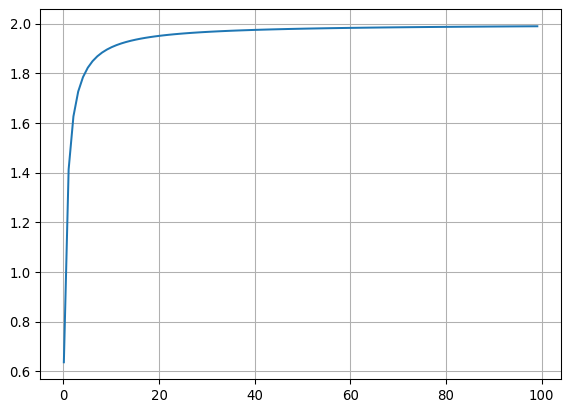

In [2]:
import numpy as np
import matplotlib.pyplot as plt
V = lambda r: 2*r**2+2*r+1
Delta = lambda r: (np.log(V(r+1))-np.log(V(r)))/(np.log(r+1)-np.log(r))
xn = np.arange(0.1, 100,1)
fig, ax = plt.subplots()
ax.plot(xn, Delta(xn))
ax.grid()
plt.show()

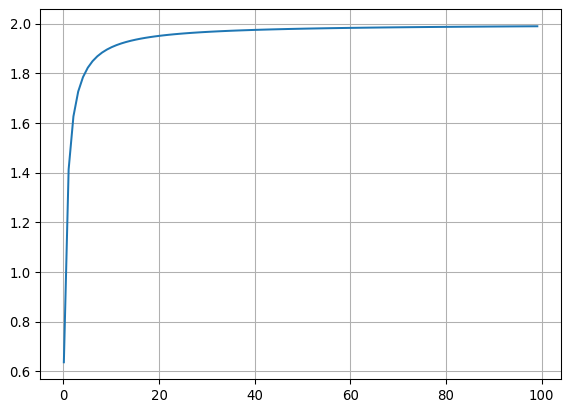

In [3]:
import numpy as np
import matplotlib.pyplot as plt
V = lambda r: 2*r**2+2*r+1
Delta = lambda r: (np.log(V(r+1))-np.log(V(r)))/(np.log(r+1)-np.log(r))
xn = np.arange(0.1, 100,1)
fig, ax = plt.subplots()
ax.plot(xn, Delta(xn))
ax.grid()
plt.show()

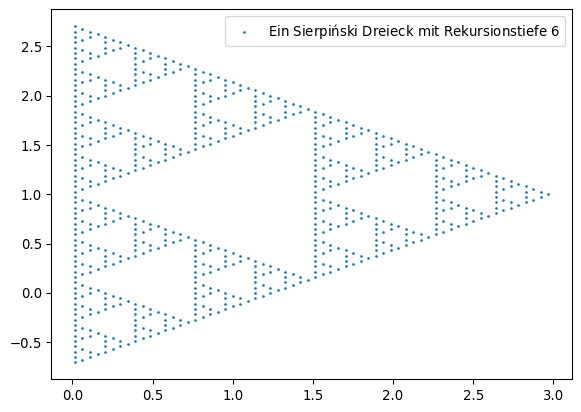

In [4]:
import matplotlib.pyplot as plt
import numpy as np

sirp = lambda x: [[],[],[]] if x==[] else [ sirp(v) for v in x]
repeat = lambda f,x,n: f(x) if n==1 else f(repeat(f,x,n-1))
points = []
start  = np.array([1,1])
angle  = 2*np.pi/3       # Winkel zwischen Punkten
length = 1               # Anfangslänge eines Punktes zum nächsten
decay  = 0.5             # Koeffizient, mit dem bei jeder Iterationstiefe die Länge zwischen Punkten sinkt
def calc(data, current_point=start, length=length):
    if len(data)==0:
        points.append(current_point)
    for i in range(len(data)):
        newpoint = current_point+np.array([
            length * np.cos(angle * i),
            length * np.sin(angle * i),
        ])
        calc(data[i], newpoint, length*decay)

# Sierpiński Dreieck mit Rekursionstiefe rt
rt = 6
data = repeat(sirp, [], rt)
calc(data)

# Zeichnen
x, y = np.array(points).T
fig, ax = plt.subplots()
ax.scatter(x, y, s=1)
plt.legend(['Ein Sierpiński Dreieck mit Rekursionstiefe $'+str(rt)+'$'])
plt.show()

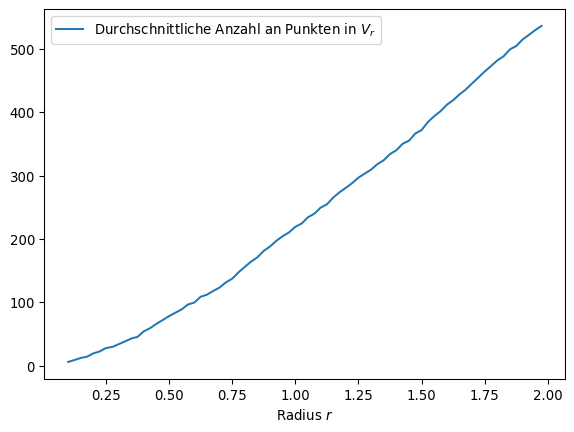

In [5]:
rn = np.arange(0.1,2,0.025)
d = np.hypot
U = lambda r,p: [ q for q in points if d(*(p-q))<=r ]
V = lambda r,p: len(U(r,p))
def avg(r):
    """berechne die durchschnittliche Anzahl an Punkten in einer r großen Umgebung
    """
    total = 0
    for p in points:
        total += V(r,p)
    total /= len(points)
    return total

val = [avg(r) for r in rn]
fig, ax = plt.subplots()
ax.plot(rn, val)
plt.xlabel('Radius $r$')
plt.legend(['Durchschnittliche Anzahl an Punkten in $V_r$'])
plt.show()

<>:9: SyntaxWarning:

invalid escape sequence '\D'

<>:10: SyntaxWarning:

invalid escape sequence '\D'

<>:9: SyntaxWarning:

invalid escape sequence '\D'

<>:10: SyntaxWarning:

invalid escape sequence '\D'

/tmp/ipykernel_165586/2060184105.py:9: SyntaxWarning:

invalid escape sequence '\D'

/tmp/ipykernel_165586/2060184105.py:10: SyntaxWarning:

invalid escape sequence '\D'



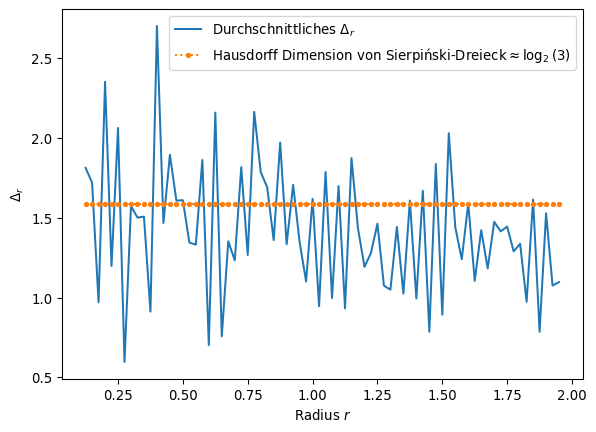

In [6]:
dn = [rn[i] for i in range(1,len(rn)-1)]
Delta = lambda i: (np.log(val[i+1])-np.log(val[i]))/(np.log(rn[i+1])-np.log(rn[i]))
dval = [Delta(i) for i in range(len(dn))]

fig, ax = plt.subplots()
ax.plot(dn, dval)
ax.plot(dn, [np.log2(3) for _ in dn], '.:')
plt.xlabel('Radius $r$')
plt.ylabel('$\Delta_r$')
plt.legend(['Durchschnittliches $\Delta_r$', 'Hausdorff Dimension von Sierpiński-Dreieck$\\approx\\log_2(3)$'])